**2. Visual Inspection of LOC EEG Data** <br>

This notebook performs the visual quality check of the EEG data after it has been converted into BIDS format. <br> The goal is to assess the overall signal quality, integrity of the recorded event markers, and interpolate bad channels.

In [ ]:
# 1. Import modules
import numpy as np
import mne
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path
import os

# 2. Configuration of file path for processed data. Adapt for the given participant.
bids_root = Path(r"C:\Users\noahm\projects\loc_analysis\data\derivatives")
sub_number = "14"
task = "loc"
suffix = "eeg"

# Define Output Filenames
deriv_root = bids_root  / f"sub-{sub_number}" / "eeg"

# Output: Annotations CSV
fname_annots = deriv_root / f"sub-{sub_number}_task-{task}_desc-annotations.csv"
print(f"Working on Subject: {sub_number}")

Working on Subject: 14
<class 'type'>


#### 2.1 Checking the integrity of event markers

C:\Users\noahm\AppData\Local\Temp\ipykernel_24108\2498058687.py:11: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['HEOG', 'VEOG']
  raw_eeg, bids_event_id = read_raw_bids(
C:\Users\noahm\AppData\Local\Temp\ipykernel_24108\2498058687.py:11: RuntimeWarning: Not setting positions of 2 eog channels found in montage:
['HEOG', 'VEOG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw_eeg, bids_event_id = read_raw_bids(
C:\Users\noahm\AppData\Local\Temp\ipykernel_24108\2498058687.py:24: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig_ev = mne.viz.plot_events(


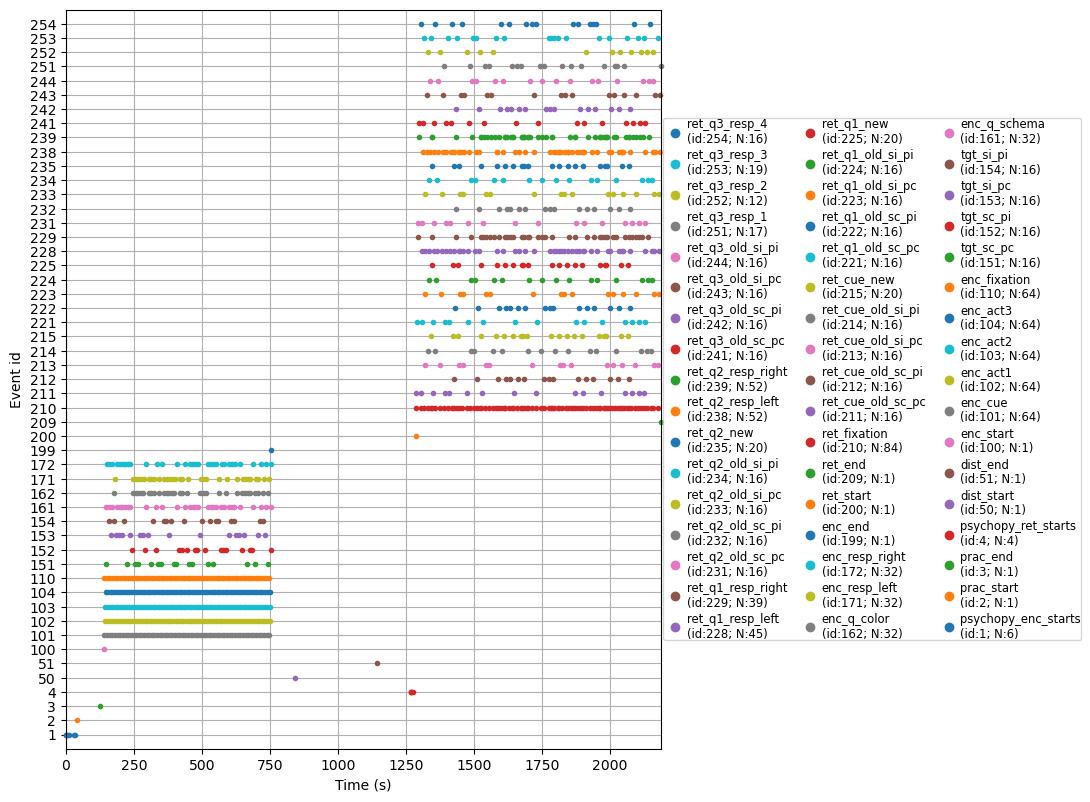

<class 'numpy.ndarray'>
<class 'dict'>
[[   1803       0       1]
 [   1824       0       1]
 [   5076       0       1]
 ...
 [2183953       0     243]
 [2187789       0     251]
 [2188368       0     209]]


In [ ]:
# 1. Define BIDS Path
bids_path = BIDSPath(
    root=bids_root, 
    subject=sub_number, 
    task=task, 
    datatype="eeg", 
    suffix=suffix
)

# 2. Load Raw
raw_eeg, bids_event_id = read_raw_bids(
    bids_path=bids_path, 
    return_event_dict=True,  # <--- HIER: Extrahiert das Mapping direkt aus BIDS
    verbose=False
)
# 3. Load events
events, event_id = mne.events_from_annotations(
    raw_eeg, 
    event_id=bids_event_id,  # <--- Überschreibt den "auto" Parser
    verbose=False
)

# 4. Plot event markers as function of experiment run time
fig_ev = mne.viz.plot_events(
    events, 
    sfreq=raw_eeg.info["sfreq"], 
    first_samp=raw_eeg.first_samp, 
    event_id=event_id
)

#### 2.2 Visual inspection of the continuous EEG signal

In [31]:
# Generating a visual overview of the raw data (10s epochs, 32 channels)
fig = raw_eeg.plot(
    duration=10, 
    n_channels=32, 
    scalings=dict(eeg=20e-6),
    theme="light" 
)

#### 2.3 Visual inspection of the power spectrum density

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


c:\Users\noahm\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


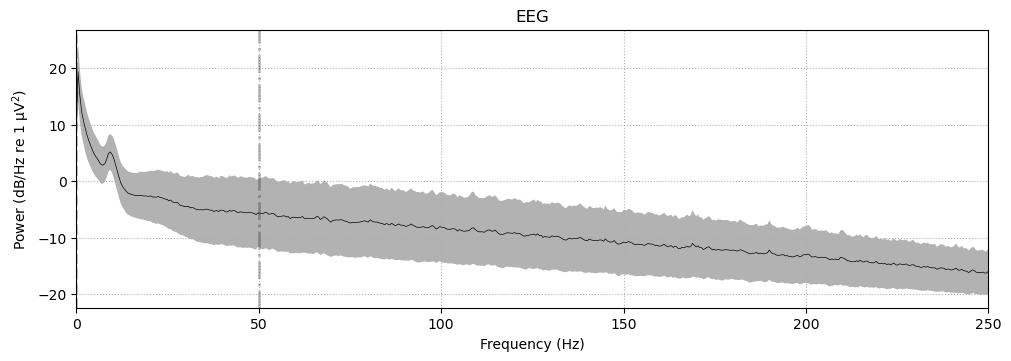

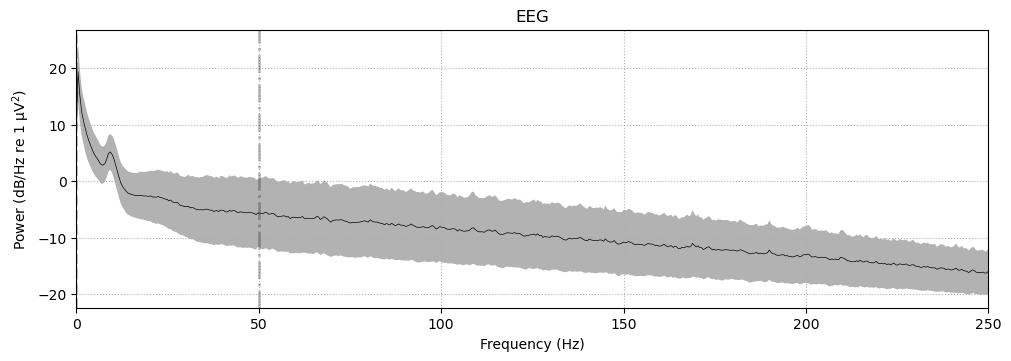

In [5]:
# 2. Plot PSD (Power Line Noise check)
raw_eeg.compute_psd(tmax=np.inf, fmax=250).plot(
    average=True, picks="data", exclude="bads"
)

In [15]:
raw_eeg.info['bads'] = []

#### 2.4 Bad Channel Inspection (Topo Plots)

No bad channels marked yet. Generating diagnostic plots...
Plotting topomap for event: 'enc_fixation' (ID: 110)
Not setting metadata
64 matching events found


Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


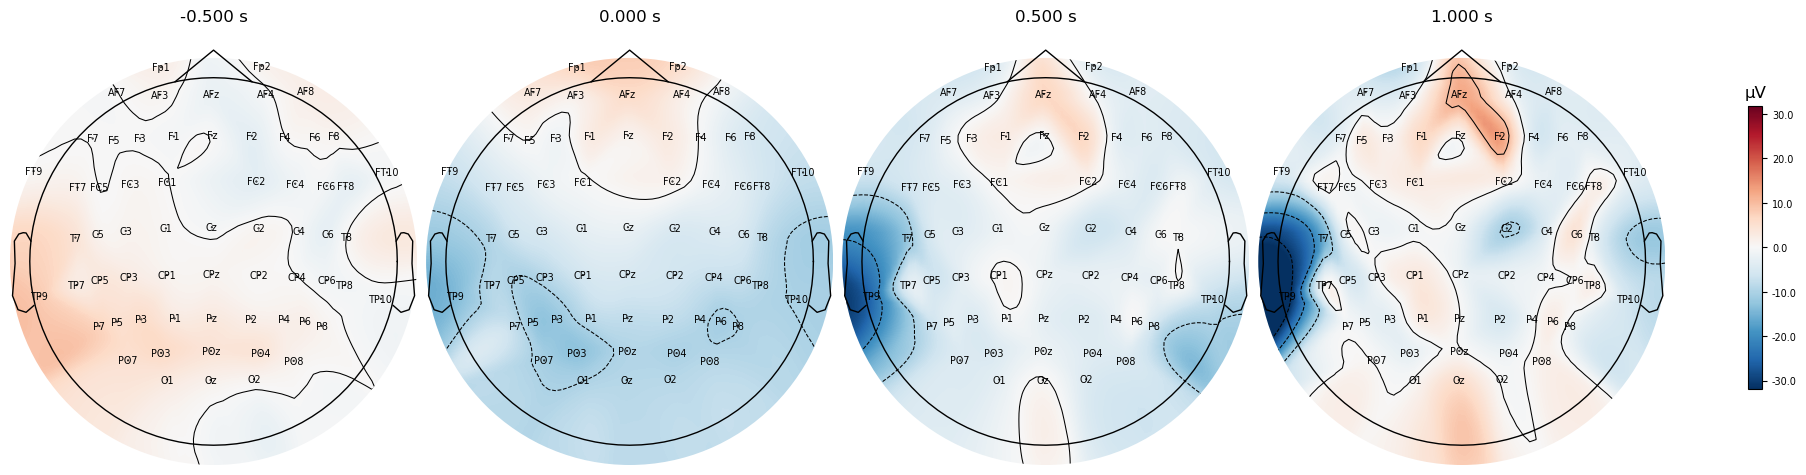

Plotting topomap for event: 'ret_fixation' (ID: 210)
Not setting metadata
84 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


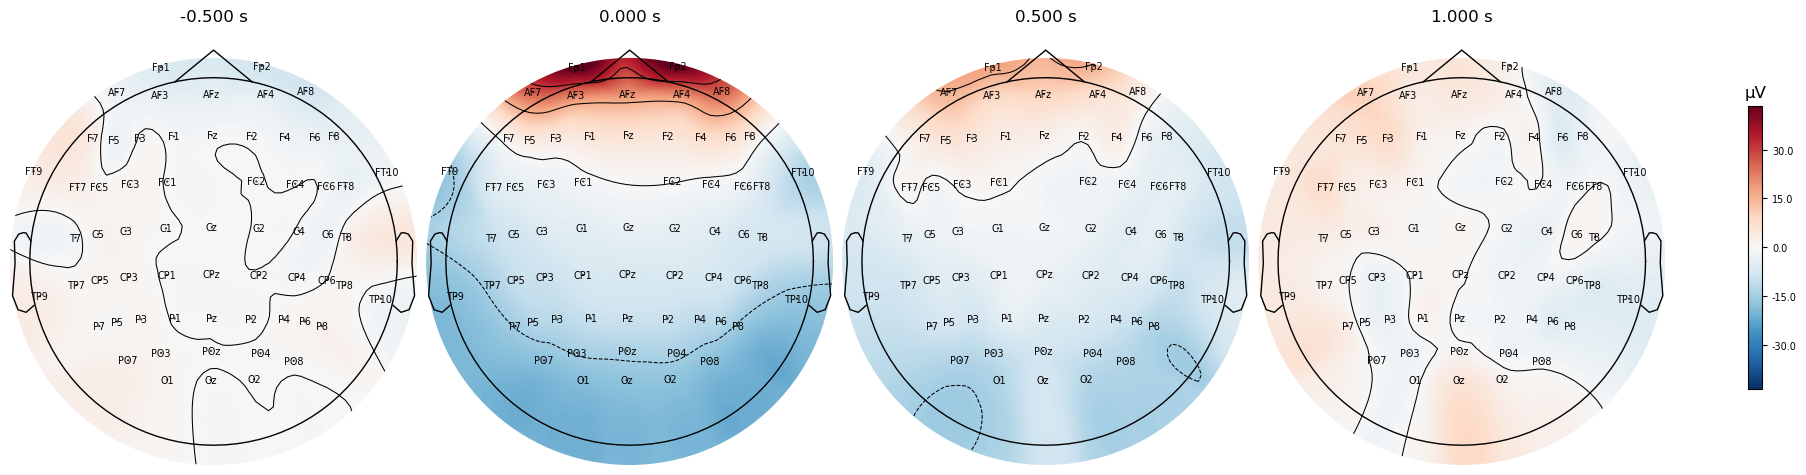

In [25]:
# 1. Check if bads are already marked
current_bads = raw_eeg.info['bads']

if len(current_bads) > 0:
    print(f"Bad channels are already marked: {current_bads}")
    print("Skipping automatic visualization. (If you want to re-check, clear 'raw_eeg.info['bads']' first).")

else:
    print("No bad channels marked yet. Generating diagnostic plots...")

    # 2. Define both events as list of tuples: (name, id)
    target_events = [
        ('enc_fixation', 110),
        ('ret_fixation', 210),
    ]

    for event_name, event_id in target_events:

        # 3. Extract events for this specific event only
        events, _ = mne.events_from_annotations(
            raw_eeg,
            event_id={event_name: event_id},
            verbose=False
        )

        # 4. Check if the target ID exists
        if event_id not in events[:, 2]:
            print(f"Warning: Event ID {event_id} ('{event_name}') not found. Skipping.")
            continue

        print(f"Plotting topomap for event: '{event_name}' (ID: {event_id})")

        # 5. Create Epochs
        epochs_viz = mne.Epochs(
            raw_eeg,
            events,
            event_id={event_name: event_id},
            tmin=-0.5, tmax=1,
            # baseline=(None, 0),
            # preload=True,
            reject_by_annotation=True,
            # verbose=False
        )

        # 6. Plot Topomap
        #    Look for "Red" or "Blue" spots that look completely different from neighbors
        fig_topo = epochs_viz.average().plot_topomap(
            show_names=True,
            size=3,
            nrows = 1  # Zur Unterscheidung
        )

Updated Bad Channels: ['T7', 'TP9']
Reading 0 ... 2223119  =      0.000 ...  2223.119 secs...
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.7 mm
Computing interpolation matrix from 61 sensor positions
Interpolating 2 sensors

--- Checking bad channels for: 'enc_fixation' (ID 110) ---
Plotting bad channels BEFORE interpolation...


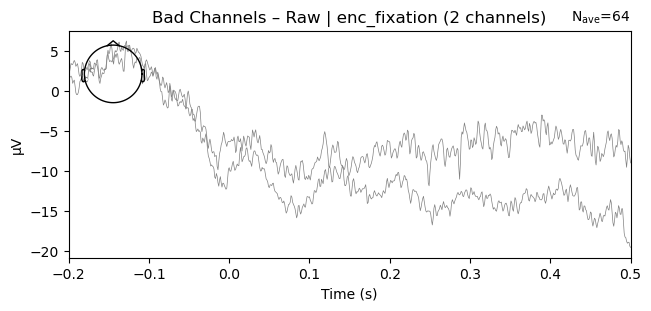

Simulating interpolation for verification...


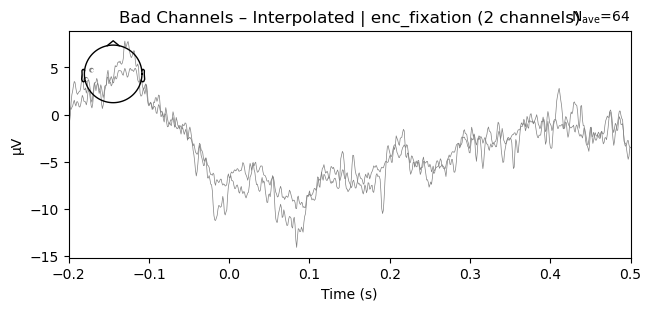


--- Checking bad channels for: 'ret_fixation' (ID 210) ---
Plotting bad channels BEFORE interpolation...


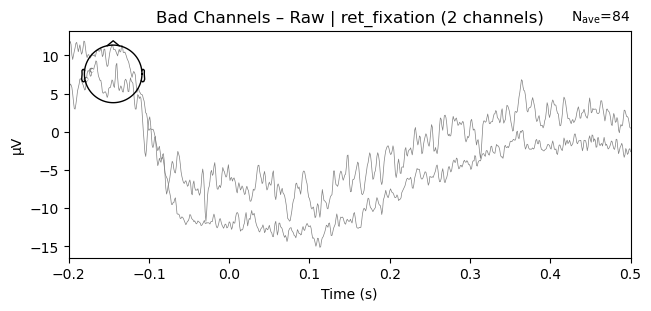

Simulating interpolation for verification...


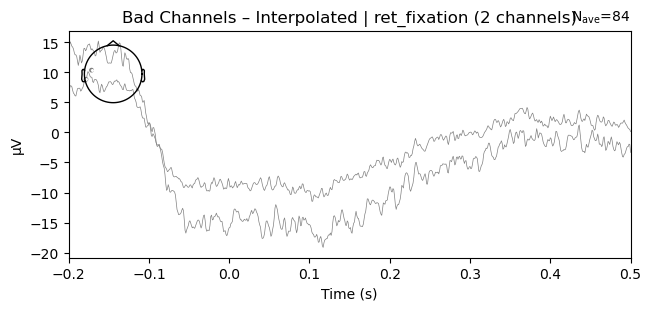

In [27]:
# ---------------------------------------------------------
# STEP 8: MARK BADS & VERIFY INTERPOLATION
# ---------------------------------------------------------

# 1. DEFINE BAD CHANNELS MANUALLY HERE
new_bads = ['TP9', 'T7']

# Add them to the raw object
if new_bads:
    raw_eeg.info['bads'].extend(new_bads)
    raw_eeg.info['bads'] = list(set(raw_eeg.info['bads']))
    print(f"Updated Bad Channels: {raw_eeg.info['bads']}")
else:
    print(f"No new bad channels added. Current bads: {raw_eeg.info['bads']}")

# 2. Verify with Interpolation (Visual Check Only)
if raw_eeg.info['bads']:

    # Define both events — same Struktur wie in Step 7
    target_events = [
        ('enc_fixation', 110),
        ('ret_fixation', 210),
    ]

    # Simulate interpolation once (not per event)
    raw_interp = raw_eeg.copy().load_data().interpolate_bads(reset_bads=False)

    for event_name, event_id in target_events:

        # Re-extract events for this condition
        events, _ = mne.events_from_annotations(
            raw_eeg,
            event_id={event_name: event_id},
            verbose=False
        )

        if event_id not in events[:, 2]:
            print(f"Warning: Event ID {event_id} ('{event_name}') not found. Skipping.")
            continue

        print(f"\n--- Checking bad channels for: '{event_name}' (ID {event_id}) ---")

        # --- PLOT 1: BEFORE (The Broken Bone) ---
        print("Plotting bad channels BEFORE interpolation...")
        epochs_bad = mne.Epochs(
            raw_eeg, events,
            event_id={event_name: event_id},
            tmin=-0.2, tmax=0.5,
            reject=None, verbose=False
        )
        epochs_bad.average().plot(
            picks=new_bads,
            exclude=[],
            titles=f"Bad Channels – Raw | {event_name}"
        )

        # --- PLOT 2: AFTER (The Verification) ---
        print("Simulating interpolation for verification...")
        events_interp, _ = mne.events_from_annotations(
            raw_interp,
            event_id={event_name: event_id},
            verbose=False
        )
        epochs_clean = mne.Epochs(
            raw_interp, events_interp,
            event_id={event_name: event_id},
            tmin=-0.2, tmax=0.5,
            reject=None, verbose=False
        )
        epochs_clean.average().plot(
            picks=new_bads,
            exclude=[],
            titles=f"Bad Channels – Interpolated | {event_name}"
        )

else:
    print("No bad channels to interpolate.")

In [28]:
# ---------------------------------------------------------
# STEP 9: SAVE DATA & LOG BAD CHANNELS
# ---------------------------------------------------------
import pandas as pd
from datetime import datetime

# 1. SAVE THE EEG DATA (With Bad Channels Marked)
# ---------------------------------------------------
# We save the file with the bad channels listed in 'raw_eeg.info['bads']'
# We do NOT save the interpolated version (raw_interp) to disk yet.
# This preserves the ability to run ICA correctly later.

#raw_eeg.save(fname_downsampled, overwrite=True)
#print(f"Saved preprocessed EEG to: {fname_downsampled}")
#print(f"(Contains: Downsampling + Annotations + Bad Channel Marks)")


# 2. SAVE BAD CHANNELS TO CSV LOG
# ---------------------------------------------------
# Define the log file path
log_file = bids_root  / "bad_channels_log.csv"

# Prepare the new entry
new_entry = {
    'subject_id': f"sub-{sub_number}",
    'bad_channels': ";".join(raw_eeg.info['bads']),  # "AF8;Cz" format
    'count': len(raw_eeg.info['bads']),
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M"),
    'notes': "Visual Inspection Complete"
}

# Check if log exists
if log_file.exists():
    df_log = pd.read_csv(log_file)
    
    # Check if subject already exists, if so, update their row
    if new_entry['subject_id'] in df_log['subject_id'].values:
        print(f"   Updating existing entry for {new_entry['subject_id']}...")
        # Update the row matching the subject_id
        idx = df_log.index[df_log['subject_id'] == new_entry['subject_id']]
        df_log.loc[idx, ['bad_channels', 'count', 'timestamp']] = \
            [new_entry['bad_channels'], new_entry['count'], new_entry['timestamp']]
    else:
        # Append new subject
        df_new = pd.DataFrame([new_entry])
        df_log = pd.concat([df_log, df_new], ignore_index=True)
else:
    # Create new DataFrame if file doesn't exist
    df_log = pd.DataFrame([new_entry])

# Save back to CSV
df_log.to_csv(log_file, index=False)
print(f"Logged bad channels to: {log_file}")
print("-" * 30)
print("Pipeline Complete!")

   Updating existing entry for sub-14...
Logged bad channels to: C:\Users\noahm\projects\loc_analysis\data\derivatives\bad_channels_log.csv
------------------------------
Pipeline Complete!
